# 1장 실습 — 환경 설정과 LIF 뉴런 첫걸음

**Spiking Neural Networks 쿡북 with Python** · 1장 실습 노트북

이 노트북에서는 snnTorch 개발 환경을 갖추고, 가장 기본이 되는 **LIF(누설 적분-발화) 뉴런** 하나를 직접 만들어 본다. 입력 전류를 시간에 따라 흘려보내며 막전위가 어떻게 누적되고 스파이크가 발생하는지 눈으로 확인한 뒤, 마지막으로 데이터를 스파이크로 바꾸는 **레이트 인코딩**을 맛본다.

### 학습 목표
- snnTorch·PyTorch 실행 환경을 구축한다.
- `snn.Leaky`로 LIF 뉴런을 만들고 시간 스텝을 따라 순전파한다.
- 막전위·스파이크를 시각화하고 감쇠율 `beta`의 의미를 이해한다.
- 정적인 값을 스파이크 열로 바꾸는 레이트 코딩을 실험한다.

> 이 책의 실습 코드는 가독성을 위해 `if`문과 `try/except` 예외처리를 사용하지 않는다.

## 1. 환경 설정

`snntorch`는 PyTorch 위에서 동작하는 스파이킹 신경망 라이브러리다. 아래 셀로 한 번만 설치하면 된다(이미 설치돼 있으면 건너뛴다). `koreanize-matplotlib`은 그래프에 한글이 깨지지 않게 해준다.

In [1]:
# 필요한 패키지 설치 (Colab 등 새 환경에서 1회 실행)
%pip install -q snntorch koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


## 2. 라이브러리 임포트

각 라이브러리의 역할은 다음과 같다.
- `torch`: 텐서 연산과 자동미분의 기반
- `snntorch`(`snn`): 스파이킹 뉴런(`snn.Leaky` 등)을 제공
- `matplotlib`: 막전위·스파이크 시각화

재현성을 위해 난수 시드를 고정한다.

In [2]:
import torch                      # 텐서 연산·자동미분
import snntorch as snn            # 스파이킹 뉴런 라이브러리
import matplotlib.pyplot as plt   # 그래프
import koreanize_matplotlib       # 그래프 한글 폰트 자동 설정

torch.manual_seed(42)            # 난수 시드 고정 → 매번 같은 결과

print('torch 버전:', torch.__version__)
print('snntorch 버전:', snn.__version__)

torch 버전: 2.9.1
snntorch 버전: 0.9.4


## 3. LIF 뉴런 하나 만들기 — `snn.Leaky`

`snn.Leaky`는 LIF 뉴런 한 개(또는 한 층)를 만든다. 핵심 인자는 두 가지다.
- `beta`: **감쇠율**. 이전 막전위를 이번 스텝에 얼마나 유지할지(0~1). 클수록 과거를 오래 기억한다.
- `threshold`: **발화 임계값**. 막전위가 이 값을 넘으면 스파이크(1)를 내고 막전위를 리셋한다.

막전위는 내부 상태이므로, 시작 전에 `init_leaky()`로 0에서 출발시킨다.

In [3]:
beta = 0.8        # 감쇠율: 이전 막전위의 80%를 유지(나머지는 누설)
threshold = 1.0   # 발화 임계값

lif = snn.Leaky(beta=beta, threshold=threshold)   # LIF 뉴런 1개 생성
mem = lif.init_leaky()                            # 막전위 초기 상태(0)

print('초기 막전위:', mem)

초기 막전위: tensor([])


## 4. 입력 전류를 시간에 따라 흘려보내기

SNN은 입력을 **여러 시간 스텝에 걸쳐** 처리한다. 여기서는 200스텝 동안 입력 전류를 단계적으로 키우며, 매 스텝마다 `lif(입력, 막전위)`를 호출해 `(스파이크, 갱신된 막전위)`를 돌려받는다. 막전위가 임계값을 넘는 순간 스파이크가 1이 되고 막전위는 리셋된다.

`for` 루프가 곧 **시간의 흐름**이며, 막전위 `mem`이 스텝 사이를 이어주는 기억이다.

In [4]:
num_steps = 200   # 총 시간 스텝 수

# 입력 전류: 0~49스텝은 0, 50~124스텝은 0.25, 125~199스텝은 0.40 (점점 강해짐)
cur_in = torch.cat([
    torch.zeros(50),
    torch.ones(75) * 0.25,
    torch.ones(75) * 0.40,
]).unsqueeze(1)   # 형태를 (num_steps, 1)로 맞춘다

mem = lif.init_leaky()   # 막전위 초기화
mem_rec = []             # 막전위 기록용
spk_rec = []             # 스파이크 기록용

# 시간 스텝을 한 칸씩 전진: 누설 → 입력 누적 → 임계 비교 → 발화/리셋
for step in range(num_steps):
    spk, mem = lif(cur_in[step], mem)   # 한 시간 스텝 진행
    spk_rec.append(spk)                 # 이번 스텝 스파이크 저장
    mem_rec.append(mem)                 # 이번 스텝 막전위 저장

spk_rec = torch.stack(spk_rec)   # 리스트 → 텐서 (num_steps, 1)
mem_rec = torch.stack(mem_rec)

print('총 스파이크 수:', int(spk_rec.sum().item()))

총 스파이크 수: 27


## 5. 막전위와 스파이크 시각화

위 칸은 입력 전류, 아래 칸은 막전위다. 막전위가 임계값(점선)에 닿을 때마다 스파이크(위쪽 삼각형)가 발생하고 막전위가 뚝 떨어지는(리셋) 톱니 모양을 확인할 수 있다. 입력이 커지는 후반부일수록 발화가 잦아진다.

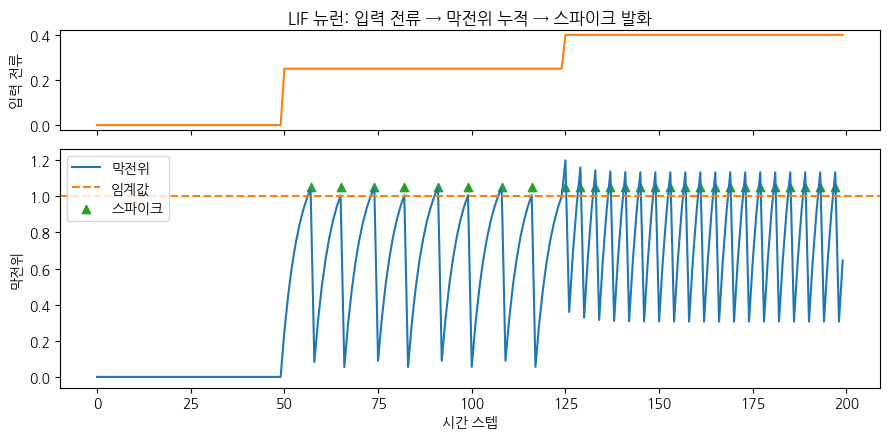

In [5]:
# 기록을 1차원 배열로 변환
cur = cur_in.squeeze().detach().numpy()
mem_v = mem_rec.squeeze().detach().numpy()
spk_t = torch.where(spk_rec.squeeze() > 0)[0].numpy()   # 스파이크가 난 시점

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 4.5), sharex=True,
                               gridspec_kw={'height_ratios': [1, 2.4]})

ax1.plot(cur, color='tab:orange')          # 입력 전류
ax1.set_ylabel('입력 전류')
ax1.set_title('LIF 뉴런: 입력 전류 → 막전위 누적 → 스파이크 발화')

ax2.plot(mem_v, color='tab:blue', label='막전위')        # 막전위
ax2.axhline(threshold, color='tab:orange', linestyle='--', label='임계값')
ax2.scatter(spk_t, [threshold + 0.05] * len(spk_t),
            marker='^', color='tab:green', label='스파이크')
ax2.set_ylabel('막전위')
ax2.set_xlabel('시간 스텝')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

### 직접 해보기
`beta`를 `0.5`나 `0.95`로 바꿔 다시 실행해 보자. `beta`가 작으면 막전위가 빨리 새어나가 발화가 줄고, 크면 과거 입력이 오래 남아 발화가 늘어난다.

## 6. 스파이크 인코딩 맛보기 — 레이트 코딩

SNN에 정적인 데이터(예: 이미지 픽셀 값)를 넣으려면 먼저 **스파이크 열**로 바꿔야 한다. 가장 단순한 방법인 **레이트 코딩**은 값(0~1)을 발화 확률로 보고, 매 스텝 베르누이 시행으로 0/1을 뽑는다. 값이 클수록 더 자주 발화한다.

In [6]:
num_steps = 100

# 세 개의 밝기 값(0.9, 0.5, 0.1)을 각각 스파이크 열로 변환
values = torch.tensor([0.9, 0.5, 0.1])                 # 발화 확률
prob = values.unsqueeze(0).repeat(num_steps, 1)        # (num_steps, 3)
spikes = torch.bernoulli(prob)                         # 확률대로 0/1 생성

rates = spikes.mean(dim=0)   # 각 값의 실제 발화 비율
print('목표 값  :', values.tolist())
print('발화 비율:', [round(r, 2) for r in rates.tolist()])

목표 값  : [0.8999999761581421, 0.5, 0.10000000149011612]
발화 비율: [0.93, 0.55, 0.13]


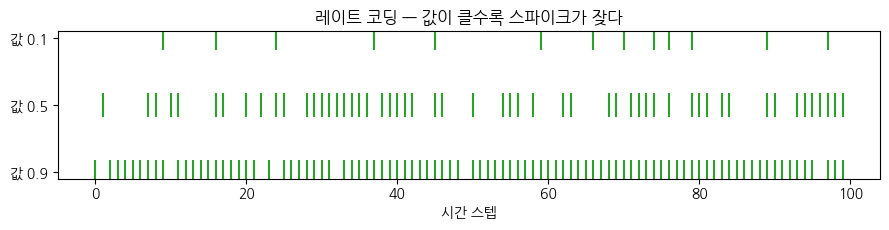

In [7]:
# 세 뉴런의 스파이크 열을 래스터 플롯으로 시각화
fig, ax = plt.subplots(figsize=(9, 2.4))

# 각 뉴런(열)에 대해 스파이크가 난 시점에 세로 막대를 찍는다
for n in range(spikes.shape[1]):
    times = torch.where(spikes[:, n] > 0)[0].numpy()
    ax.scatter(times, [n] * len(times), marker='|', s=300, color='tab:green')

ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['값 0.9', '값 0.5', '값 0.1'])
ax.set_xlabel('시간 스텝')
ax.set_title('레이트 코딩 — 값이 클수록 스파이크가 잦다')
plt.tight_layout()
plt.show()

## 정리

- `snn.Leaky(beta, threshold)`로 LIF 뉴런을 만들고, `init_leaky()`로 막전위를 초기화한다.
- 매 시간 스텝마다 `spk, mem = lif(입력, mem)`을 호출하면 누설·누적·발화·리셋이 한 번에 처리된다.
- 감쇠율 `beta`는 뉴런의 기억 길이를, 임계값은 발화 민감도를 결정한다.
- 레이트 코딩은 값(0~1)을 발화 확률로 보고 스파이크 열을 만든다.

다음 2장 실습에서는 이 뉴런들을 층으로 쌓아 MNIST를 분류하는 **첫 스파이킹 신경망**을 끝까지 학습시킨다.